# Long-Range Entanglement with Dynamic Circuits

## How to entangle distant qubits without long SWAP chains
---

### What This Notebook Covers

On real quantum hardware, qubits can only interact with their **nearest neighbors**. So if you want to apply a CNOT gate between qubit 0 and qubit 60, the traditional approach requires a long chain of SWAP gates to "move" the qubits next to each other — and each SWAP adds noise.

**Dynamic circuits** offer an alternative: instead of physically moving quantum information through SWAP chains, we can use **mid-circuit measurements and classical feedforward** to teleport entanglement across the chip in **constant depth** — regardless of distance!

In this notebook, we will:

1. **Understand the theory** behind Bell pairs, gate teleportation, and the Long-Range CX (LRCX) protocol
2. **Build the dynamic LRCX circuit** step by step, with explanations at each stage
3. **Build a unitary baseline** using SWAP decomposition for comparison
4. **Execute both approaches** on real IBM Quantum hardware
5. **Compare fidelity vs. distance** to see when dynamic circuits outperform unitary ones

---

## Background: The Theory Behind Long-Range Entanglement

### The Problem: Qubit Connectivity

Real quantum processors have a **fixed topology** — each qubit connects only to a few neighbors. IBM's Heron processors use a **heavy-hex lattice**, where most qubits have 2–3 neighbors.

To apply a two-qubit gate (like CNOT) between distant qubits, the standard approach is a **SWAP chain**:

```
Qubit 0 --SWAP-- Qubit 1 --SWAP-- Qubit 2 -- ... --SWAP-- Qubit N --CNOT-- Qubit N+1
```

Each SWAP decomposes into 3 CNOT gates. For distance $d$, this requires $O(d)$ two-qubit gates — and each gate introduces errors.

### The Solution: Gate Teleportation

**Gate teleportation** is a quantum communication protocol that uses pre-shared entanglement (Bell pairs) to apply a gate between distant qubits without physically moving them.

The key insight: **creating many Bell pairs in parallel is cheap** (constant depth), and **measurements + classical processing are fast**. So we can:

1. Create a chain of Bell pairs linking qubit 0 to qubit N
2. Perform Bell basis measurements on neighboring pairs to "fuse" the entanglement
3. Apply classically-conditioned corrections based on measurement outcomes
4. The net effect is a CNOT between the endpoints — in **constant depth**!

### What Is a Bell Pair?

A **Bell pair** (or Bell state) is the simplest form of entanglement between two qubits:

$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$

Created by applying a Hadamard gate followed by a CNOT:

```
q0: ── H ──●──
           │
q1: ─────⊕──
```

### What Is a Bell Basis Measurement?

In **Bell basis measurement**, we measure two observables:

- **XX measurement**: Tells us the parity in the X basis
- **ZZ measurement**: Tells us the parity in the Z basis

The ZZ measurement is implemented as: CNOT → measure the target qubit.  
The XX measurement is implemented as: CNOT → H → measure the control qubit.

### The LRCX Protocol (Simplified)

Here's the step-by-step idea for a Long-Range CX (LRCX) between a **control** qubit and a **target** qubit separated by $n$ intermediate qubits:

1. **Prepare Bell pairs** along the path between control and target
2. **Bell basis measurements** on overlapping pairs to fuse the entanglement chain
3. **Classical feedforward corrections** — depending on measurement outcomes, apply X and/or Z corrections
4. **Result**: A CNOT gate between control and target, achieved in constant circuit depth!

The corrections needed are determined by the **parity** of the measurement results:
- Odd parity of ZZ measurements → apply X on the target
- Odd parity of XX measurements → apply Z on the control

---

## 1. Setup and Imports

In [1]:
# Standard libraries
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Qiskit core
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.classical import expr        # Classical expression framework for feedforward logic
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_circuit_layout

# Qiskit IBM Runtime
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    Batch,
    SamplerV2 as Sampler,
)

# Plotting style
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

---

## 2. Connect to IBM Quantum Backend

In [6]:
# Initialize the Qiskit Runtime service
service = QiskitRuntimeService()

dc_backends = service.backends(
    dynamic_circuits=True, operational=True, simulator=False, min_num_qubits=50
)

# Prefer Heron r2 processors
heron_r2 = [
    b
    for b in dc_backends
    if "heron" in b.processor_type.get("family", "").lower()
    and int(b.processor_type.get("revision", "0")) >= 2
]

if not heron_r2:
    raise RuntimeError("No Heron r2 backend currently available.")

# Select least busy → fresher calibration + shorter queue
backend = min(heron_r2, key=lambda b: b.status().pending_jobs)

print(f"✓ Backend selected: {backend.name}")
print(f"Processor: {backend.processor_type}")
print(f"Pending jobs: {backend.status().pending_jobs}")
print(f"Qubits: {backend.num_qubits}")

✓ Backend selected: ibm_marrakesh
Processor: {'family': 'Heron', 'revision': '2'}
Pending jobs: 0
Qubits: 156


---

## 3. Configuration

We'll test several **distances** (number of intermediate qubits between control and target). At each distance, we measure in three bases (XX, YY, ZZ) to compute Bell state fidelity.

In [7]:
# Distances to test: number of intermediate qubits between control and target
# distance=0 means control and target are neighbors (no intermediates)
# distance=60 means 60 qubits sit between control and target (62 total qubits used)
# DISTANCES = [0, 20, 40, 60]
DISTANCES = [
20, 30, 40
]

# Measurement bases for Bell state fidelity reconstruction
BASIS_LIST = ["XX", "YY", "ZZ"]

# Number of independent trial runs for statistical averaging
NUM_TRIALS = 5

# Shots per circuit execution
SHOTS = 1024

# Transpilation optimization level
# Level 1 matches the IBM tutorial — sufficient when we provide initial_layout
OPTIMIZATION_LEVEL = 1

print("Configuration:")
print(f"  Distances:          {DISTANCES}")
print(f"  Bases:              {BASIS_LIST}")
print(f"  Trials per config:  {NUM_TRIALS}")
print(f"  Shots per circuit:  {SHOTS}")
print(f"  Optimization level: {OPTIMIZATION_LEVEL}")
print(f"  Unique circuits:    {len(DISTANCES) * len(BASIS_LIST) * 2}")
print(f"                      ({len(DISTANCES)} distances x {len(BASIS_LIST)} bases x 2 methods)")
print(f"  Total submissions:  {len(DISTANCES) * len(BASIS_LIST) * 2 * NUM_TRIALS} circuit runs")

Configuration:
  Distances:          [20, 30, 40]
  Bases:              ['XX', 'YY', 'ZZ']
  Trials per config:  5
  Shots per circuit:  1024
  Optimization level: 1
  Unique circuits:    18
                      (3 distances x 3 bases x 2 methods)
  Total submissions:  90 circuit runs


---

## 4. Building the Dynamic LRCX Circuit (Step by Step)

The Long-Range CX (LRCX) protocol has five stages:

| Stage | What Happens | Circuit Depth |
|-------|-------------|---------------|
| 1. Initialize | Put control qubit in superposition | O(1) |
| 2. Bell pairs | Create entangled pairs along the path | O(1) — all pairs in parallel |
| 3. Bell measurements | Measure overlapping pairs to fuse chains | O(1) |
| 4. Feedforward | Apply corrections based on measurement parity | O(1) |
| 5. Final measurement | Measure control + target in chosen basis | O(1) |

**Total depth: O(1)** — independent of distance! Compare this to the SWAP chain approach which scales as O(distance).

### 4.1 Initialize the Circuit

We set up a quantum circuit with:
- `n + 2` qubits: 1 control + n intermediate + 1 target
- Classical registers for final measurement (`cr`), ZZ parity bits (`c1`), and XX parity bits (`c2`)
- A Hadamard gate on the control qubit to create the initial superposition

The Hadamard prepares the control qubit in state $\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$, so after the CNOT we expect the Bell state $\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$.

In [8]:
def initialize_circuit(distance):
    """
    Create the initial circuit for the LRCX protocol.
    
    Sets up quantum register with (distance + 2) qubits and the necessary
    classical registers for mid-circuit measurement results.
    
    Args:
        distance: Number of intermediate qubits between control and target.
                  distance=0 means control and target are neighbors.
    
    Returns:
        QuantumCircuit with Hadamard on control qubit (qubit 0).
    """
    assert distance >= 0, "Distance must be non-negative"
    
    control = 0
    n = distance  # number of intermediate qubits
    
    # Create quantum register: control + n intermediates + target
    qr = QuantumRegister(n + 2, name="q")
    
    # Classical register for final measurement of control and target
    cr = ClassicalRegister(2, name="cr")
    
    # Number of ZZ measurement bits needed
    k = int(n / 2)
    
    # Build list of classical registers
    allcr = [cr]
    
    if distance > 1:
        # c1 stores ZZ parity measurement outcomes
        c1 = ClassicalRegister(k, name="c1")
        allcr.append(c1)
    
    if distance > 0:
        # c2 stores XX parity measurement outcomes
        c2 = ClassicalRegister(n - k, name="c2")
        allcr.append(c2)
    
    qc = QuantumCircuit(qr, *allcr, name="CNOT")
    
    # Put control qubit in superposition
    # This creates |+> = (|0> + |1>) / sqrt(2)
    qc.h(control)
    
    return qc

### 4.2 Prepare Bell Pairs Along the Path

We create a chain of Bell pairs connecting the control qubit to the target. Each pair is created by applying H + CNOT on adjacent qubits.

**Key insight:** All Bell pairs can be created **simultaneously** in a single layer of gates, because they act on non-overlapping qubit pairs. This is what gives us constant depth!

```
For even distance (e.g., distance=4, 6 qubits total):

q0: ─H─●──────────    (control qubit, already in |+>)
q1: ───⊕─────────
q2: ─────H─●─────    Bell pair 1
q3: ───────⊕────
q4: ─────H─●─────    Bell pair 2
q5: ───────⊕────    (target qubit)
```

In [9]:
def check_even(n: int) -> int:
    """Helper: returns 1 if n is even, else 2.
    
    This determines the starting index for Bell pair creation,
    accounting for even/odd distance layouts.
    """
    return 1 if n % 2 == 0 else 2


def prepare_bell_pairs(qc, add_barriers=True):
    """
    Create a chain of Bell pairs along the qubit path.
    
    For even distance n:
      - Control qubit 0 is paired with qubit 1 (via the initial H + later CNOT)
      - Pairs: (1,2), (3,4), (5,6), ... created with H + CNOT
    
    For odd distance n:
      - Control paired with qubit 1 via CNOT
      - Pairs: (2,3), (4,5), ... created with H + CNOT
    
    All Bell pairs are created in parallel (constant depth).
    
    Args:
        qc: QuantumCircuit from initialize_circuit()
        add_barriers: Whether to add visual barriers for clarity
    
    Returns:
        Modified QuantumCircuit with Bell pairs prepared.
    """
    n = qc.num_qubits - 2  # number of intermediate qubits
    k = int(n / 2)         # number of ZZ measurement pairs
    
    if add_barriers:
        qc.barrier()
    
    x0 = check_even(n)  # starting index for Bell pair creation
    
    # For odd distance, entangle control with its neighbor first
    if n % 2 != 0:
        qc.cx(0, 1)
    
    # Create Bell pairs in parallel: H followed by CNOT on adjacent pairs
    for i in range(k):
        qc.h(x0 + 2 * i)
        qc.cx(x0 + 2 * i, x0 + 2 * i + 1)
    
    return qc

### 4.3 Bell Basis Measurements

Now we "fuse" the Bell pairs by performing Bell basis measurements on overlapping qubit pairs. This projects pairs of qubits and, through the magic of entanglement, extends the entanglement from control to target.

A Bell basis measurement on qubits $(i, i+1)$ consists of:
1. **CNOT** from qubit $i$ to qubit $i+1$ (for ZZ parity)
2. **Hadamard + measure** on qubit $i$ (for XX parity)
3. **Measure** qubit $i+1$ (for ZZ parity)

The measurement outcomes are stored in classical registers `c1` (ZZ) and `c2` (XX) for use in feedforward corrections.

In [10]:
def measure_bell_basis(qc, add_barriers=True):
    """
    Perform Bell basis measurements on overlapping pairs to fuse entanglement.
    
    This is the heart of the gate teleportation protocol. By measuring
    intermediate qubits in the Bell basis, we project the entanglement
    chain onto a direct entanglement between control and target.
    
    The measurement outcomes (stored in c1 and c2) tell us which Pauli
    byproduct corrections are needed.
    
    Args:
        qc: QuantumCircuit with Bell pairs prepared
        add_barriers: Whether to add visual barriers
    
    Returns:
        Modified QuantumCircuit with Bell measurements applied.
    """
    n = qc.num_qubits - 2
    k = int(n / 2)
    
    # Get classical registers for storing measurement results
    if n > 1:
        _, c1, c2 = qc.cregs  # cr, c1 (ZZ bits), c2 (XX bits)
    elif n > 0:
        _, c2 = qc.cregs      # cr, c2 (XX bits only for distance=1)
    
    x0 = 1 if n % 2 == 0 else 2
    
    # Step 1: Apply CNOTs to disentangle ZZ parity
    # CNOT from even-index qubit to odd-index qubit of each overlapping pair
    for i in range(k + 1):
        qc.cx(x0 - 1 + 2 * i, x0 + 2 * i)
    
    # Step 2: Apply Hadamard gates to prepare XX measurement
    for i in range(1, k + x0):
        qc.h(2 * i + 1 - x0)
    
    if add_barriers:
        qc.barrier()
    
    # Step 3: Mid-circuit measurements
    # Store ZZ outcomes in c1
    for i in range(k):
        qc.measure(2 * i + x0, c1[i])
    
    # Store XX outcomes in c2
    for i in range(1, k + x0):
        qc.measure(2 * i + 1 - x0, c2[i - 1])
    
    return qc

### 4.4 Feedforward Corrections

The Bell basis measurements introduce random **Pauli byproduct operators** (X and Z errors) that depend on the measurement outcomes. We must correct these classically-conditioned errors to complete the gate teleportation.

The correction rule:
- If the **XOR parity of all ZZ measurements** (register `c1`) is 1 → apply **X gate** on the target qubit
- If the **XOR parity of all XX measurements** (register `c2`) is 1 → apply **Z gate** on the control qubit

This uses Qiskit's **classical expression framework** (`qiskit.circuit.classical.expr`) to compute XOR parities and conditionally apply gates — all within the circuit, executed in real-time on the quantum hardware's classical control system.

In [11]:
def apply_ffwd_corrections(qc):
    """
    Apply classically-conditioned feedforward corrections.
    
    Uses the mid-circuit measurement outcomes to determine which
    Pauli corrections are needed to complete the gate teleportation.
    
    The parity computations use Qiskit's expr framework:
    - expr.lift(bit) converts a classical bit to an expression
    - expr.bit_xor(a, b) computes XOR between expressions
    - qc.if_test(expr) conditionally applies gates
    
    Args:
        qc: QuantumCircuit with Bell measurements completed
    
    Returns:
        Modified QuantumCircuit with corrections applied.
    """
    control = 0
    target = qc.num_qubits - 1
    n = qc.num_qubits - 2
    k = int(n / 2)
    x0 = check_even(n)
    
    # Get classical registers
    if n > 1:
        _, c1, c2 = qc.cregs
    elif n > 0:
        _, c2 = qc.cregs
    
    # Compute ZZ parity: XOR of all c1 bits
    # If parity is odd (1), we need to flip the target qubit
    for i in range(k):
        if i == 0:
            parity_ZZ = expr.lift(c1[i])  # Start with first bit
        else:
            parity_ZZ = expr.bit_xor(c1[i], parity_ZZ)  # XOR with running parity
    
    # Compute XX parity: XOR of all c2 bits
    # If parity is odd (1), we need to apply phase flip on control
    for i in range(1, k + x0):
        if i == 1:
            parity_XX = expr.lift(c2[i - 1])
        else:
            parity_XX = expr.bit_xor(c2[i - 1], parity_XX)
    
    # Apply corrections conditioned on parities
    if n > 0:
        with qc.if_test(parity_XX):
            qc.z(control)  # Phase correction on control
    
    if n > 1:
        with qc.if_test(parity_ZZ):
            qc.x(target)   # Bit-flip correction on target
    
    return qc

### 4.5 Final Measurement in Chosen Basis

To reconstruct the Bell state fidelity, we need expectation values of three Pauli operators: $\langle XX \rangle$, $\langle YY \rangle$, and $\langle ZZ \rangle$.

Each requires measuring in a different basis:

| Basis | Pre-measurement gates | What we learn |
|-------|----------------------|---------------|
| **ZZ** | None (computational basis) | $\langle Z_c Z_t \rangle$ |
| **XX** | H on both qubits | $\langle X_c X_t \rangle$ |
| **YY** | S† then H on both qubits | $\langle Y_c Y_t \rangle$ |

In [12]:
def measure_in_basis(qc, basis="XX", add_barrier=True):
    """
    Measure control and target qubits in the specified Pauli basis.
    
    To measure in a non-Z basis, we rotate into that basis before
    measuring in the computational (Z) basis:
      - XX: Apply H to both qubits, then measure
      - YY: Apply S-dagger then H to both qubits, then measure
      - ZZ: Just measure directly
    
    Args:
        qc: QuantumCircuit with LRCX protocol applied
        basis: One of "XX", "YY", "ZZ"
        add_barrier: Whether to add a visual barrier
    
    Returns:
        New QuantumCircuit (copy) with basis rotation + measurements.
    """
    control = 0
    target = qc.num_qubits - 1
    assert basis in ["XX", "YY", "ZZ"], f"Unknown basis: {basis}"
    
    # Work on a copy so we can create circuits for different bases
    qc = qc.copy()
    cr = qc.cregs[0]  # Final measurement register
    
    if add_barrier:
        qc.barrier()
    
    # Apply basis rotation gates
    if basis == "XX":
        # H rotates Z-eigenstates to X-eigenstates
        qc.h(control)
        qc.h(target)
    elif basis == "YY":
        # S-dagger followed by H rotates Z to Y
        qc.sdg(control)
        qc.sdg(target)
        qc.h(control)
        qc.h(target)
    # ZZ: no rotation needed
    
    # Measure control and target
    qc.measure(control, cr[0])
    qc.measure(target, cr[1])
    
    return qc

### 4.6 Putting It All Together: The Complete LRCX Circuit

Now we combine all stages into a single function that builds the complete dynamic LRCX circuit for any distance.

In [13]:
def lrcx(distance, prep_barrier=True, pre_measure_barrier=True):
    """
    Build the complete dynamic Long-Range CX circuit.
    
    Combines all stages of the LRCX protocol:
    1. Initialize circuit with H on control
    2. Prepare Bell pair chains
    3. Bell basis measurements to fuse entanglement
    4. Classical feedforward corrections
    
    Note: This returns the circuit WITHOUT final measurement.
    Use measure_in_basis() to add measurement in the desired basis.
    
    Args:
        distance: Number of intermediate qubits (0 = neighbors)
        prep_barrier: Add barrier after Bell pair preparation
        pre_measure_barrier: Add barrier before mid-circuit measurements
    
    Returns:
        QuantumCircuit implementing the LRCX protocol (before final measurement).
    """
    qc = initialize_circuit(distance)
    qc = prepare_bell_pairs(qc, prep_barrier)
    qc = measure_bell_basis(qc, pre_measure_barrier)
    qc = apply_ffwd_corrections(qc)
    return qc

### 4.7 Visualize the Dynamic LRCX Circuit

Let's draw the circuit for a small distance to see all the stages in action.

Dynamic LRCX circuit for distance=4 (XX measurement):
  Total qubits: 6
  Circuit depth: 8



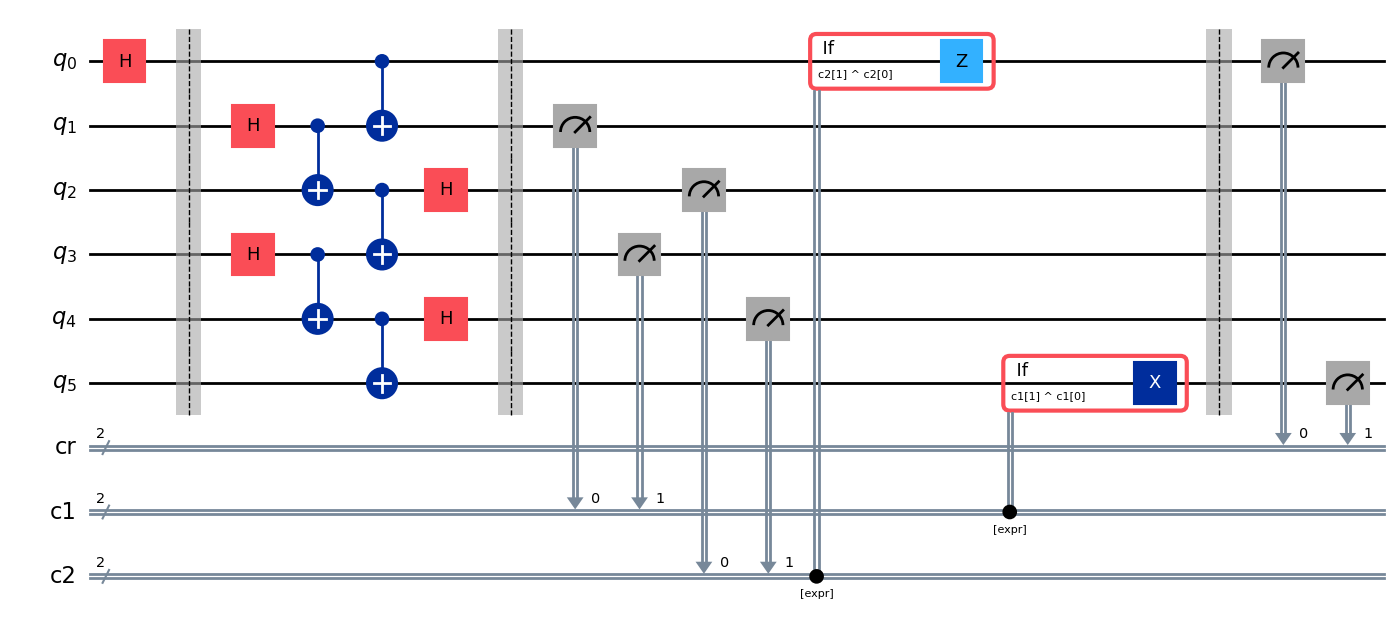

In [11]:
# Build and visualize LRCX for distance=4 (6 qubits total)
# This is a good size to see all the protocol stages clearly
demo_lrcx = lrcx(4)
demo_lrcx_xx = measure_in_basis(demo_lrcx, basis="ZZ")

print(f"Dynamic LRCX circuit for distance=4 (XX measurement):")
print(f"  Total qubits: {demo_lrcx_xx.num_qubits}")
print(f"  Circuit depth: {demo_lrcx_xx.depth()}")
print()

demo_lrcx_xx.draw('mpl', fold=-1, idle_wires=False)

---

## 5. Building the Unitary Baseline (SWAP Chain)

For comparison, we also build the **unitary** (traditional) approach: move the control qubit to the middle using SWAP gates, apply the CNOT, then move back.

Each SWAP is decomposed into 3 CNOTs:
```
SWAP(a,b) = CNOT(a,b) + CNOT(b,a) + CNOT(a,b)
```

For distance $d$, this uses the trick of SWAPping from both ends toward the middle simultaneously, then applying the CNOT at the center, and SWAPping back. The circuit depth scales as **O(d)** — much worse than the constant-depth dynamic approach.

In [14]:
def cnot_unitary(distance):
    """
    Build a unitary (SWAP-based) long-range CNOT circuit.
    
    Strategy: SWAP control and target toward the center, apply CNOT
    at the center, then SWAP them back to their original positions.
    
    This is the traditional approach without dynamic circuits.
    Circuit depth scales linearly with distance: O(d).
    
    Args:
        distance: Number of intermediate qubits (0 = neighbors)
    
    Returns:
        QuantumCircuit implementing unitary long-range CNOT.
    """
    assert distance >= 0
    
    n = distance
    qr = QuantumRegister(n + 2, name="q")
    cr = ClassicalRegister(2, name="cr")
    qc = QuantumCircuit(qr, cr, name="CNOT_unitary")
    
    control_qubit = 0
    k = int(n / 2)
    
    # Prepare superposition on control (same as dynamic case)
    qc.h(control_qubit)
    qc.barrier()
    
    # SWAP from both ends toward the center
    # Each SWAP = 3 CNOTs: CX(a,b) CX(b,a) CX(a,b)
    for i in range(control_qubit, control_qubit + k):
        # SWAP from the control side (left)
        qc.cx(i, i + 1)
        qc.cx(i + 1, i)
        # SWAP from the target side (right)
        qc.cx(-i - 1, -i - 2)
        qc.cx(-i - 2, -i - 1)
    
    # Handle odd distance: one extra SWAP needed
    if n % 2 == 1:
        qc.cx(k + 2, k + 1)
        qc.cx(k + 1, k + 2)
    
    qc.barrier()
    
    # Apply the actual CNOT at the center
    qc.cx(k, k + 1)
    
    # SWAP back: reverse the process
    for i in range(control_qubit, control_qubit + k):
        qc.cx(k - i, k - 1 - i)
        qc.cx(k - 1 - i, k - i)
        qc.cx(k + i + 1, k + i + 2)
        qc.cx(k + i + 2, k + i + 1)
    
    if n % 2 == 1:
        qc.cx(-2, -1)
        qc.cx(-1, -2)
    
    return qc

### 5.1 Visualize the Unitary Circuit

Let's compare the unitary circuit with the dynamic one at the same distance.

Unitary CNOT circuit for distance=4 (XX measurement):
  Total qubits: 6
  Circuit depth: 12

Comparison at distance=4:
  Dynamic LRCX depth: 8
  Unitary CNOT depth: 12



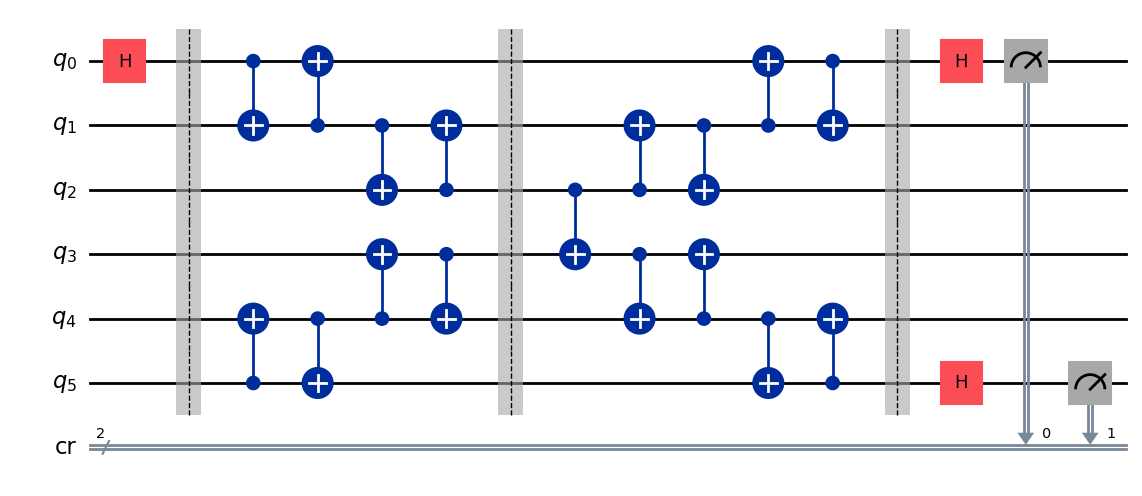

In [13]:
# Build unitary CNOT for distance=4 and add XX measurement
demo_unitary = cnot_unitary(4)
demo_unitary_xx = measure_in_basis(demo_unitary, basis="XX")

print(f"Unitary CNOT circuit for distance=4 (XX measurement):")
print(f"  Total qubits: {demo_unitary_xx.num_qubits}")
print(f"  Circuit depth: {demo_unitary_xx.depth()}")
print()
print(f"Comparison at distance=4:")
print(f"  Dynamic LRCX depth: {demo_lrcx_xx.depth()}")
print(f"  Unitary CNOT depth: {demo_unitary_xx.depth()}")
print()

demo_unitary_xx.draw('mpl', fold=-1, idle_wires=False)

---

## 6. Transpile Circuits for Hardware

Before execution, we must **transpile** the circuits to the backend's native gate set and qubit topology. This is where the depth advantage of dynamic circuits really shows up — the dynamic LRCX stays constant while the unitary approach grows linearly.

In [14]:
# ---- Select optimal qubit chains from backend layer fidelity data ----
# The backend provides pre-computed "layer fidelity" qubit chains:
# the highest-quality linear paths through the chip. We pick the longest
# chain (for max distance) and slice sub-chains for shorter distances.

try:
    lf_qubits = backend.properties().to_dict()["general_qlists"]
    max_qubits_needed = DISTANCES[-1] + 2  # e.g., 62 for distance=60
    chosen_layouts = {
        dist: [
            val["qubits"]
            for val in lf_qubits
            if val["name"] == f"lf_{max_qubits_needed}"
        ][0][: dist + 2]
        for dist in DISTANCES
    }
    print(f"Using layer-fidelity qubit chain (length {max_qubits_needed})")
    use_initial_layout = True
except Exception as e:
    print(f"Could not extract layer fidelity layouts: {e}")
    print(f"Falling back to automatic layout selection")
    chosen_layouts = {}
    use_initial_layout = False

# ---- Build and transpile circuits ONCE per (distance x basis) ----
# The tutorial transpiles each circuit once, then submits the same
# transpiled circuit multiple times for statistical averaging.
print(f"\nTranspiling circuits...")
print(f"  Distances: {DISTANCES}")
print(f"  Bases:     {BASIS_LIST}")

isa_circuits_dyn = []  # Flat list: [d0_XX, d0_YY, d0_ZZ, d1_XX, ...]
isa_circuits_uni = []  # Same ordering for unitary

depth_data = {"dynamic": {}, "unitary": {}}

for dist in DISTANCES:
    print(f"  Distance {dist:>2d} ({dist + 2} qubits)...", end=" ")

    # Build base circuits (before final measurement)
    dyn_base = lrcx(dist)
    uni_base = cnot_unitary(dist)

    # Create pass manager WITH initial_layout for this distance
    pm_kwargs = {
        "optimization_level": OPTIMIZATION_LEVEL,
        "backend": backend,
    }
    if use_initial_layout:
        pm_kwargs["initial_layout"] = chosen_layouts[dist]

    pm = generate_preset_pass_manager(**pm_kwargs)

    for basis in BASIS_LIST:
        dyn_circuit = measure_in_basis(dyn_base, basis=basis)
        uni_circuit = measure_in_basis(uni_base, basis=basis)

        isa_circuits_dyn.append(pm.run(dyn_circuit))
        isa_circuits_uni.append(pm.run(uni_circuit))

    # Record depth from the XX circuit (first of the 3 just appended)
    dyn_idx = len(isa_circuits_dyn) - 3
    uni_idx = len(isa_circuits_uni) - 3

    depth_data["dynamic"][dist] = isa_circuits_dyn[dyn_idx].depth()
    depth_data["unitary"][dist] = isa_circuits_uni[uni_idx].depth()

    print(f"dynamic depth={depth_data['dynamic'][dist]}, "
          f"unitary depth={depth_data['unitary'][dist]}")

print(f"\nTotal transpiled circuits: {len(isa_circuits_dyn) + len(isa_circuits_uni)}")
print(f"  ({len(isa_circuits_dyn)} dynamic + {len(isa_circuits_uni)} unitary)")
print(f"  Each list will be submitted {NUM_TRIALS} times for statistical averaging")

Using layer-fidelity qubit chain (length 42)

Transpiling circuits...
  Distances: [20, 30, 40]
  Bases:     ['XX', 'YY', 'ZZ']
  Distance 20 (22 qubits)... dynamic depth=20, unitary depth=123
  Distance 30 (32 qubits)... dynamic depth=20, unitary depth=173
  Distance 40 (42 qubits)... dynamic depth=20, unitary depth=223

Total transpiled circuits: 18
  (9 dynamic + 9 unitary)
  Each list will be submitted 5 times for statistical averaging


### 6.1 Visualize Depth Scaling

Let's plot how the transpiled circuit depth scales with distance for both approaches.

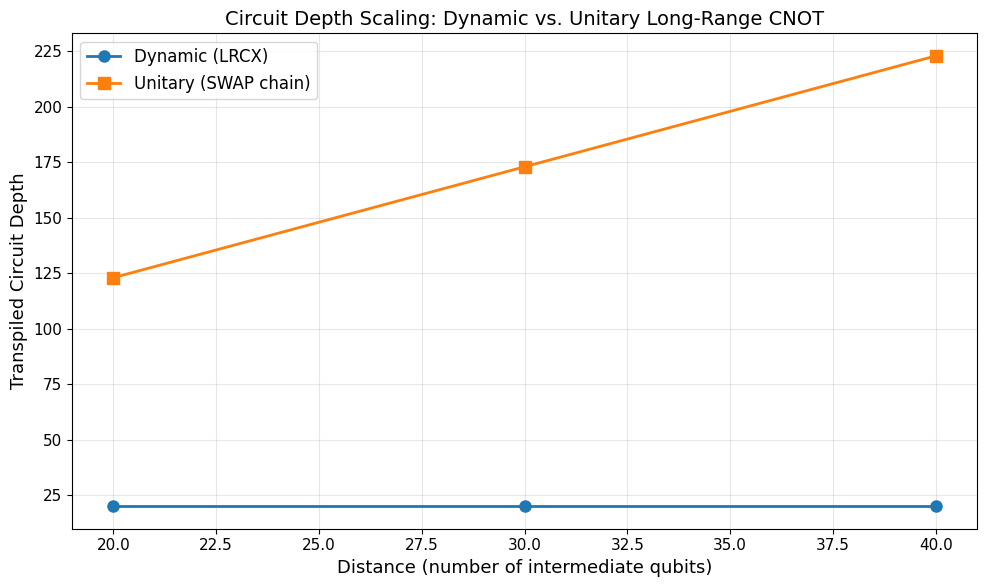

Key observation: Dynamic circuit depth stays roughly CONSTANT,
while unitary depth grows LINEARLY with distance.


In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

dists = sorted(depth_data["dynamic"].keys())
dyn_depths = [depth_data["dynamic"][d] for d in dists]
uni_depths = [depth_data["unitary"][d] for d in dists]

ax.plot(dists, dyn_depths, 'o-', color='#1f77b4', linewidth=2, markersize=8, label='Dynamic (LRCX)')
ax.plot(dists, uni_depths, 's-', color='#ff7f0e', linewidth=2, markersize=8, label='Unitary (SWAP chain)')

ax.set_xlabel('Distance (number of intermediate qubits)', fontsize=13)
ax.set_ylabel('Transpiled Circuit Depth', fontsize=13)
ax.set_title('Circuit Depth Scaling: Dynamic vs. Unitary Long-Range CNOT', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key observation: Dynamic circuit depth stays roughly CONSTANT,")
print("while unitary depth grows LINEARLY with distance.")

### 6.2 Visualize Qubit Layout on Hardware

Let's see how the qubits are mapped onto the physical hardware for a representative circuit.

Qubit layout for dynamic LRCX at distance=40:


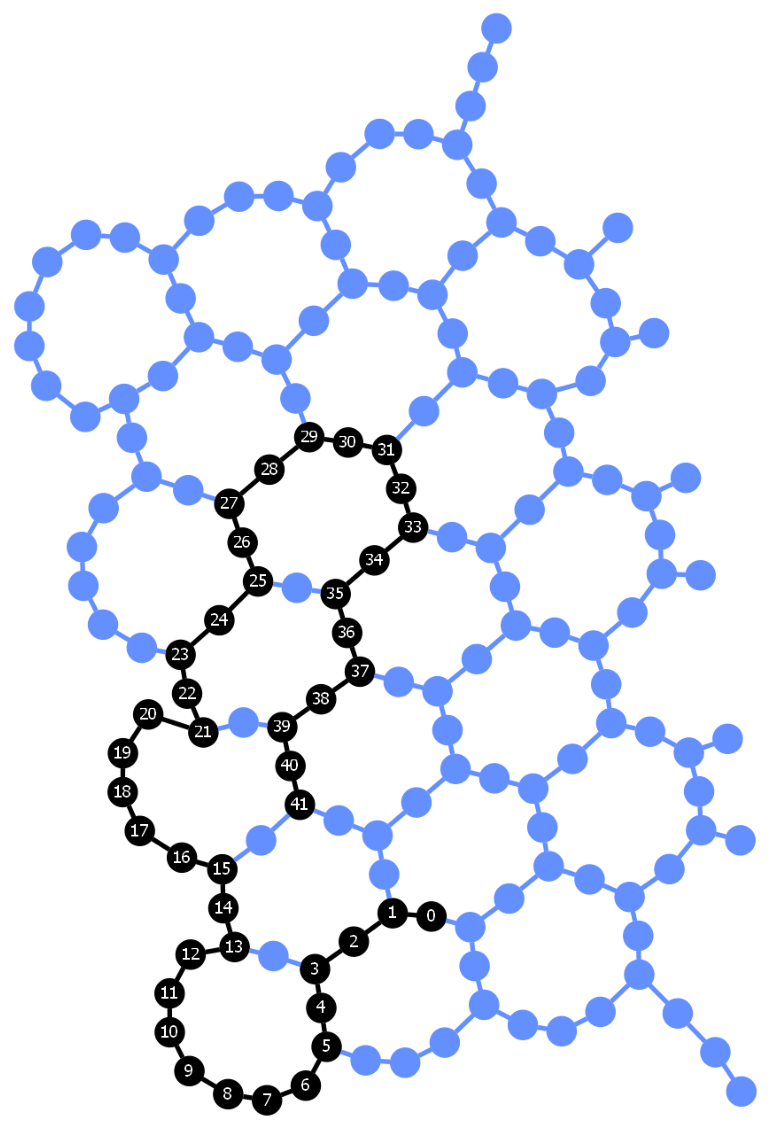

In [18]:
# Show the qubit layout for a medium-distance dynamic circuit
sample_dist = 40
sample_dist_idx = DISTANCES.index(sample_dist)
sample_circuit = isa_circuits_dyn[sample_dist_idx * 3]  # XX basis circuit

print(f"Qubit layout for dynamic LRCX at distance={sample_dist}:")
plot_circuit_layout(sample_circuit, backend)

---

## 6.5 Noisy Simulation with FakeMarrakesh

Before spending hardware credits, let's validate the full pipeline using **FakeMarrakesh** — a noisy simulator that replicates the calibration data, coupling map, and error rates of the real `ibm_marrakesh` backend.

Unlike an ideal simulator (fidelity = 1.0), FakeMarrakesh gives us **realistic fidelity estimates** that preview what we should expect on hardware. This lets us:

1. Confirm the circuit construction and transpilation are correct
2. See the depth-vs-fidelity tradeoff before touching real QPU credits
3. Observe the dynamic vs. unitary crossover even in simulation

In [19]:
from qiskit_ibm_runtime.fake_provider import FakeMarrakesh
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Fidelity helpers (defined here for early use; also in Section 9 formally)
def _sim_zz_exp(counts):
    """Compute ZZ expectation from counts."""
    total = sum(counts.values())
    return sum(
        (-1) ** int(bs[-1]) * (-1) ** int(bs[-2]) * c
        for bs, c in counts.items()
    ) / total

def _sim_fidelity(cx, cy, cz):
    """Bell state fidelity: F = 1/4 * (1 + <XX> - <YY> + <ZZ>)."""
    return 0.25 * (1 + _sim_zz_exp(cx) - _sim_zz_exp(cy) + _sim_zz_exp(cz))

# ---- Set up fake backend ----
fake_backend = FakeMarrakesh()
print(f"Fake backend: {fake_backend.name}")
print(f"Qubits:       {fake_backend.num_qubits}")

# Validate on a representative subset of distances
SIM_DISTANCES = [0, 2, 6, 16]

# Transpile circuits for the fake backend
pm_fake = generate_preset_pass_manager(
    optimization_level=OPTIMIZATION_LEVEL,
    backend=fake_backend,
)

sim_circuits_dyn = []
sim_circuits_uni = []

for dist in SIM_DISTANCES:
    dyn_base = lrcx(dist)
    uni_base = cnot_unitary(dist)
    for basis in BASIS_LIST:
        sim_circuits_dyn.append(pm_fake.run(measure_in_basis(dyn_base, basis=basis)))
        sim_circuits_uni.append(pm_fake.run(measure_in_basis(uni_base, basis=basis)))

print(f"Transpiled {len(sim_circuits_dyn)} dynamic + {len(sim_circuits_uni)} unitary circuits")

# Run on FakeMarrakesh (noisy simulation)
sim_sampler = Sampler(mode=fake_backend)
sim_result_dyn = sim_sampler.run(sim_circuits_dyn, shots=SHOTS).result()
sim_result_uni = sim_sampler.run(sim_circuits_uni, shots=SHOTS).result()

# Compute and display fidelities
print("\nFakeMarrakesh Noisy Simulation Results")
print("=" * 65)
print(f"{'Distance':>10} | {'Dynamic F':>10} | {'Unitary F':>10} | {'Winner':>10}")
print("-" * 65)

sim_fidelities = {"dynamic": {}, "unitary": {}}

for d_idx, dist in enumerate(SIM_DISTANCES):
    # Extract counts for each basis
    dyn_counts = {
        basis: sim_result_dyn[d_idx * 3 + b_idx].data.cr.get_counts()
        for b_idx, basis in enumerate(BASIS_LIST)
    }
    uni_counts = {
        basis: sim_result_uni[d_idx * 3 + b_idx].data.cr.get_counts()
        for b_idx, basis in enumerate(BASIS_LIST)
    }

    f_dyn = _sim_fidelity(dyn_counts["XX"], dyn_counts["YY"], dyn_counts["ZZ"])
    f_uni = _sim_fidelity(uni_counts["XX"], uni_counts["YY"], uni_counts["ZZ"])

    sim_fidelities["dynamic"][dist] = f_dyn
    sim_fidelities["unitary"][dist] = f_uni

    winner = "Dynamic" if f_dyn > f_uni else "Unitary"
    print(f"{dist:>10} | {f_dyn:>10.4f} | {f_uni:>10.4f} | {winner:>10}")

print("\nNote: Fidelities < 1.0 reflect realistic noise from ibm_marrakesh")
print("calibration data. Expect similar trends on real hardware.")

Fake backend: fake_marrakesh
Qubits:       156
Transpiled 12 dynamic + 12 unitary circuits

FakeMarrakesh Noisy Simulation Results
  Distance |  Dynamic F |  Unitary F |     Winner
-----------------------------------------------------------------
         0 |     0.9702 |     0.9751 |    Unitary
         2 |     0.9453 |     0.9478 |    Unitary
         6 |     0.9106 |     0.9253 |    Unitary
        16 |     0.8506 |     0.8691 |    Unitary

Note: Fidelities < 1.0 reflect realistic noise from ibm_marrakesh
calibration data. Expect similar trends on real hardware.


---

## 7. Execute on IBM Quantum Hardware

We submit all transpiled circuits using the **Batch** execution mode. Following the tutorial pattern, we submit the **same** set of 39 transpiled circuits (13 distances × 3 bases) repeatedly for `NUM_TRIALS` independent runs.

- **39 circuits per method** (13 distances × 3 bases)
- **10 trial submissions** per method for statistical averaging
- **1024 shots** per circuit per trial

**Note:** This cell submits jobs to real hardware. Execution time depends on queue wait times.

In [20]:
print("=" * 60)
print("EXECUTING ON IBM QUANTUM HARDWARE")
print("=" * 60)
print(f"Backend:           {backend.name}")
print(f"Shots:             {SHOTS}")
print(f"Circuits per job:  {len(isa_circuits_dyn)} (per method)")
print(f"Trials:            {NUM_TRIALS}")
print()

# Submit the SAME transpiled circuit lists NUM_TRIALS times each.
# This matches the tutorial approach for statistical averaging.
jobs_dyn = []
jobs_uni = []

with Batch(backend=backend) as batch:
    sampler = Sampler(mode=batch)

    for trial in range(NUM_TRIALS):
        jobs_dyn.append(sampler.run(isa_circuits_dyn, shots=SHOTS))
        jobs_uni.append(sampler.run(isa_circuits_uni, shots=SHOTS))
        print(f"  Trial {trial}: dynamic={jobs_dyn[-1].job_id()}, "
              f"unitary={jobs_uni[-1].job_id()}")

print(f"\nAll {NUM_TRIALS * 2} jobs submitted! Waiting for results...")

EXECUTING ON IBM QUANTUM HARDWARE
Backend:           ibm_marrakesh
Shots:             1024
Circuits per job:  9 (per method)
Trials:            5

  Trial 0: dynamic=d6a32blaijps73cter80, unitary=d6a32btaijps73cter9g
  Trial 1: dynamic=d6a32cbo1r9c73fmv9qg, unitary=d6a32cro1r9c73fmv9rg
  Trial 2: dynamic=d6a32d57v0is73fo5370, unitary=d6a32dd7v0is73fo537g
  Trial 3: dynamic=d6a32dtaijps73cterbg, unitary=d6a32e5aijps73ctercg
  Trial 4: dynamic=d6a32ehd1ejc73c87kdg, unitary=d6a32ero1r9c73fmva00

All 10 jobs submitted! Waiting for results...


---

## 8. Collect Results

In [21]:
print("=" * 60)
print("COLLECTING RESULTS")
print("=" * 60)

# Results are flat lists matching isa_circuits ordering:
#   index = dist_idx * 3 + basis_idx   (XX=0, YY=1, ZZ=2)

dynamic_counts = {}   # {(dist, basis, trial): counts_dict}
unitary_counts = {}

basis_to_idx = {b: i for i, b in enumerate(BASIS_LIST)}

for trial, (dyn_job, uni_job) in enumerate(zip(jobs_dyn, jobs_uni)):
    dyn_result = dyn_job.result()
    uni_result = uni_job.result()

    for d_idx, dist in enumerate(DISTANCES):
        for basis in BASIS_LIST:
            flat_idx = d_idx * 3 + basis_to_idx[basis]

            dynamic_counts[(dist, basis, trial)] = (
                dyn_result[flat_idx].data.cr.get_counts()
            )
            unitary_counts[(dist, basis, trial)] = (
                uni_result[flat_idx].data.cr.get_counts()
            )

    print(f"  Trial {trial}: collected {len(DISTANCES)} distances x "
          f"{len(BASIS_LIST)} bases")

print(f"\nAll results collected!")
print(f"  {len(dynamic_counts)} dynamic + {len(unitary_counts)} unitary count dicts")

COLLECTING RESULTS
  Trial 0: collected 3 distances x 3 bases
  Trial 1: collected 3 distances x 3 bases
  Trial 2: collected 3 distances x 3 bases
  Trial 3: collected 3 distances x 3 bases
  Trial 4: collected 3 distances x 3 bases

All results collected!
  45 dynamic + 45 unitary count dicts


---

## 9. Compute Bell State Fidelity

The Bell state fidelity quantifies how close our output is to the ideal Bell state $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$.

### Fidelity Formula

$$F = \frac{1}{4}\left(1 + \langle XX \rangle - \langle YY \rangle + \langle ZZ \rangle\right)$$

where each expectation value is computed from measurement outcomes:

$$\langle ZZ \rangle = \sum_{b_1, b_2 \in \{0,1\}} (-1)^{b_1} \cdot (-1)^{b_2} \cdot P(b_1, b_2)$$

- $F = 1$ for a perfect Bell state
- $F = 0.25$ for a completely mixed state (random noise)
- $F > 0.5$ indicates genuine entanglement

In [15]:
def compute_ZZ_expectation(counts):
    """
    Compute the ZZ expectation value from measurement counts.
    
    For a two-qubit measurement with outcomes b1, b2 in {0, 1}:
      <ZZ> = sum over all outcomes of (-1)^b1 * (-1)^b2 * P(b1, b2)
    
    This gives +1 when qubits agree (00 or 11) and -1 when they disagree (01 or 10).
    
    Args:
        counts: Dictionary of bitstring -> count
    
    Returns:
        float: Expectation value in [-1, 1]
    """
    total = sum(counts.values())
    expectation = 0
    
    for bitstring, count in counts.items():
        # Qiskit uses little-endian bit ordering:
        # bitstring[-1] is qubit 0 (control), bitstring[-2] is qubit 1 (target)
        z1 = (-1) ** int(bitstring[-1])
        z2 = (-1) ** int(bitstring[-2])
        expectation += z1 * z2 * count
    
    return expectation / total


def compute_fidelity(counts_xx, counts_yy, counts_zz):
    """
    Compute Bell state fidelity from XX, YY, ZZ measurement outcomes.
    
    F = 1/4 * (1 + <XX> - <YY> + <ZZ>)
    
    For a perfect Bell state |Phi+>: <XX> = +1, <YY> = -1, <ZZ> = +1
    So F = 1/4 * (1 + 1 - (-1) + 1) = 1/4 * 4 = 1.0
    
    Args:
        counts_xx: Measurement counts in XX basis
        counts_yy: Measurement counts in YY basis
        counts_zz: Measurement counts in ZZ basis
    
    Returns:
        float: Bell state fidelity in [0, 1]
    """
    xx = compute_ZZ_expectation(counts_xx)  # Same formula works for all bases
    yy = compute_ZZ_expectation(counts_yy)  # (we rotated into the correct basis
    zz = compute_ZZ_expectation(counts_zz)  #  before measuring in Z)
    
    return 0.25 * (1 + xx - yy + zz)


print("Fidelity functions defined.")
print("\nQuick check with ideal Bell state counts:")
ideal_xx = {'00': 512, '11': 512}    # <XX> = +1
ideal_yy = {'01': 512, '10': 512}    # <YY> = -1
ideal_zz = {'00': 512, '11': 512}    # <ZZ> = +1
print(f"  Ideal fidelity: {compute_fidelity(ideal_xx, ideal_yy, ideal_zz):.4f} (should be 1.0)")

Fidelity functions defined.

Quick check with ideal Bell state counts:
  Ideal fidelity: 1.0000 (should be 1.0)


In [23]:
print("=" * 60)
print("COMPUTING BELL STATE FIDELITIES")
print("=" * 60)

# Compute fidelity for each (distance, trial) combination
dynamic_fidelities = {}   # {distance: [fidelity_trial_0, ..., fidelity_trial_9]}
unitary_fidelities = {}   # {distance: [fidelity_trial_0, ..., fidelity_trial_9]}

for dist in DISTANCES:
    dyn_f_list = []
    uni_f_list = []
    
    for trial in range(NUM_TRIALS):
        # Compute dynamic LRCX fidelity
        dyn_f = compute_fidelity(
            dynamic_counts[(dist, "XX", trial)],
            dynamic_counts[(dist, "YY", trial)],
            dynamic_counts[(dist, "ZZ", trial)],
        )
        dyn_f_list.append(dyn_f)
        
        # Compute unitary CNOT fidelity
        uni_f = compute_fidelity(
            unitary_counts[(dist, "XX", trial)],
            unitary_counts[(dist, "YY", trial)],
            unitary_counts[(dist, "ZZ", trial)],
        )
        uni_f_list.append(uni_f)
    
    dynamic_fidelities[dist] = dyn_f_list
    unitary_fidelities[dist] = uni_f_list
    
    dyn_mean = np.mean(dyn_f_list)
    uni_mean = np.mean(uni_f_list)
    winner = "Dynamic" if dyn_mean > uni_mean else "Unitary"
    
    print(f"  Distance {dist:>2d}: Dynamic={dyn_mean:.4f}, Unitary={uni_mean:.4f}  [{winner}]")

COMPUTING BELL STATE FIDELITIES
  Distance 20: Dynamic=0.5286, Unitary=0.5869  [Unitary]
  Distance 30: Dynamic=0.4983, Unitary=0.5146  [Unitary]
  Distance 40: Dynamic=0.3749, Unitary=0.3642  [Dynamic]


---

## 10. Results Visualization

Let's create the key comparison plot: **Fidelity vs. Distance** for both approaches.

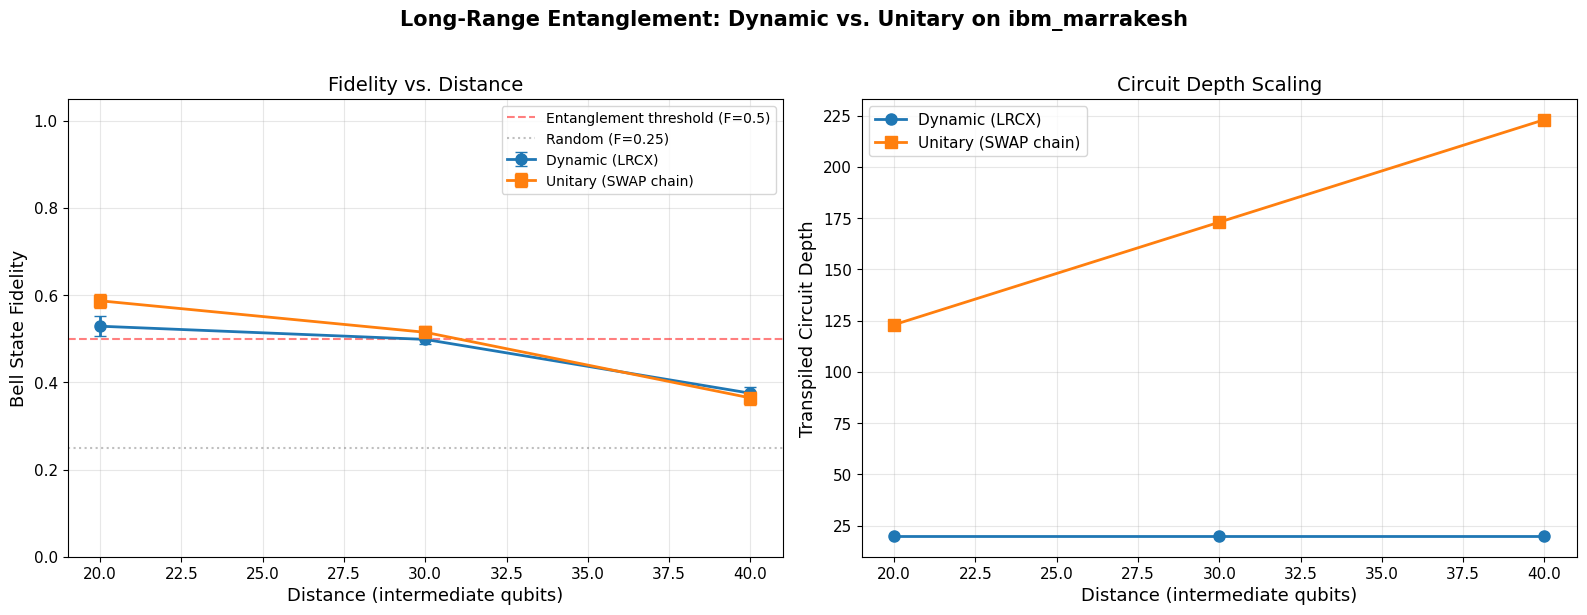

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---- Left panel: Fidelity vs Distance ----
dists = sorted(dynamic_fidelities.keys())

dyn_means = [np.mean(dynamic_fidelities[d]) for d in dists]
dyn_stds = [np.std(dynamic_fidelities[d]) for d in dists]
uni_means = [np.mean(unitary_fidelities[d]) for d in dists]
uni_stds = [np.std(unitary_fidelities[d]) for d in dists]

ax1.errorbar(dists, dyn_means, yerr=dyn_stds, fmt='o-', color='#1f77b4',
             linewidth=2, markersize=8, capsize=4, label='Dynamic (LRCX)')
ax1.errorbar(dists, uni_means, yerr=uni_stds, fmt='s-', color='#ff7f0e',
             linewidth=2, markersize=8, capsize=4, label='Unitary (SWAP chain)')

# Mark the entanglement threshold
ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Entanglement threshold (F=0.5)')
ax1.axhline(y=0.25, color='gray', linestyle=':', alpha=0.5, label='Random (F=0.25)')

ax1.set_xlabel('Distance (intermediate qubits)', fontsize=13)
ax1.set_ylabel('Bell State Fidelity', fontsize=13)
ax1.set_title('Fidelity vs. Distance', fontsize=14)
ax1.legend(fontsize=10, loc='upper right')
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)

# ---- Right panel: Depth vs Distance ----
dyn_d = [depth_data["dynamic"][d] for d in dists]
uni_d = [depth_data["unitary"][d] for d in dists]

ax2.plot(dists, dyn_d, 'o-', color='#1f77b4', linewidth=2, markersize=8, label='Dynamic (LRCX)')
ax2.plot(dists, uni_d, 's-', color='#ff7f0e', linewidth=2, markersize=8, label='Unitary (SWAP chain)')

ax2.set_xlabel('Distance (intermediate qubits)', fontsize=13)
ax2.set_ylabel('Transpiled Circuit Depth', fontsize=13)
ax2.set_title('Circuit Depth Scaling', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Long-Range Entanglement: Dynamic vs. Unitary on {backend.name}',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 11 Dynamical Decoupling: Unitary DD vs Dynamic Stretch DD

Idle qubits accumulate **decoherence errors** (T1 decay, T2 dephasing) while waiting for other operations to complete. **Dynamical Decoupling (DD)** combats this by inserting carefully timed pulse sequences (X–Rz–X–Rz) during idle periods to refocus unwanted interactions with the environment.

Two flavours are compared here:

| Approach | How DD Is Applied | Benefit |
|----------|------------------|---------|
| **Unitary + DD** | Standard `PadDynamicalDecoupling` transpiler pass fills idle slots automatically | Reduces decoherence in the long SWAP chains |
| **Dynamic + Stretch DD** | `qc.add_stretch()` inserts DD on control & target qubits while they wait for mid-circuit measurement results | Fills the measurement-latency gap that otherwise causes idle decoherence |

We test at larger distances **[25, 35, 45, 55]** where the depth / measurement-wait overhead is most pronounced, with **5 trials × 3 bases × 4 distances × 2 methods = 120 circuit runs**.

In [16]:
from qiskit.circuit.library import RZGate, XGate
from qiskit.transpiler.passes import ALAPScheduleAnalysis, PadDynamicalDecoupling
from qiskit.transpiler import PassManager

# ============================================================
# DD Configuration
# ============================================================
DD_DISTANCES = [25, 35, 45, 55]
DD_TRIALS = 5

In [17]:
# ---- 1. Stretch DD helper for dynamic circuits ----
# Inserts X–Rz(π)–X–Rz(−π) DD sequence padded by stretch delays
# on a single qubit, to fill idle time during mid-circuit measurement.


def add_stretch_dd(qc, q, name):
    """Insert a stretch-based DD sequence on qubit q."""
    s = qc.add_stretch(name)
    qc.delay(s, q)  # S
    qc.x(q)
    qc.delay(s, q)  # S×2 (first half)
    qc.delay(s, q)  # S×2 (second half)
    qc.rz(np.pi, q)
    qc.x(q)
    qc.rz(-np.pi, q)
    qc.delay(s, q)  # S
    return qc


def lrcx_stretch_dd(distance):
    """Build dynamic LRCX with Stretch DD on control & target.

    Reuses existing helpers; inserts DD between Bell measurements
    and feedforward corrections — exactly where control & target
    sit idle waiting for measurement results.
    """
    qc = initialize_circuit(distance)
    qc = prepare_bell_pairs(qc, add_barriers=True)
    qc = measure_bell_basis(qc, add_barriers=True)

    # Insert stretch DD on control and target during measurement wait
    if distance > 0:
        control = 0
        target = qc.num_qubits - 1
        qc = add_stretch_dd(qc, control, f"control_{distance}")
        qc = add_stretch_dd(qc, target, f"target_{distance}")

    qc = apply_ffwd_corrections(qc)
    return qc

In [18]:
# ---- 2. DD transpiler pass manager for unitary circuits ----
# Uses ALAPScheduleAnalysis + PadDynamicalDecoupling with
# X–Rz(π)–X–Rz(−π) sequence and spacing [1/4, 1/2, 0, 0, 1/4].


def make_dd_pass_manager(backend_obj, initial_layout=None):
    """Create a pass manager with DD scheduling for unitary circuits."""
    pm_kwargs = {"optimization_level": OPTIMIZATION_LEVEL, "backend": backend_obj}
    if initial_layout is not None:
        pm_kwargs["initial_layout"] = initial_layout
    pm = generate_preset_pass_manager(**pm_kwargs)

    pm.scheduling = PassManager(
        [
            ALAPScheduleAnalysis(target=backend_obj.target),
            PadDynamicalDecoupling(
                dd_sequence=[XGate(), RZGate(np.pi), XGate(), RZGate(-np.pi)],
                spacing=[1 / 4, 1 / 2, 0, 0, 1 / 4],
                target=backend_obj.target,
            ),
        ]
    )
    return pm

In [19]:
# ---- 3. Build & transpile ----
print("Building DD comparison circuits...")
print(f"  Distances: {DD_DISTANCES}")
print(f"  Trials:    {DD_TRIALS}")

isa_dd_uni = []  # Unitary + DD   (flat: 4 dists × 3 bases = 12)
isa_dd_dyn = []  # Dynamic + Stretch DD

dd_depth = {"uni_dd": {}, "dyn_stretch": {}}

for dist in DD_DISTANCES:
    # Build abstract circuits
    uni_base = cnot_unitary(dist)
    dyn_base = lrcx_stretch_dd(dist)

    # Transpile unitary with DD pass manager
    pm_dd = make_dd_pass_manager(backend)
    # Standard pm for dynamic stretch (stretch resolved at compile time)
    pm_std = generate_preset_pass_manager(
        optimization_level=OPTIMIZATION_LEVEL, backend=backend
    )

    for basis in BASIS_LIST:
        isa_dd_uni.append(pm_dd.run(measure_in_basis(uni_base, basis=basis)))
        isa_dd_dyn.append(pm_std.run(measure_in_basis(dyn_base, basis=basis)))

    dd_depth["uni_dd"][dist] = isa_dd_uni[-3].depth()
    dd_depth["dyn_stretch"][dist] = isa_dd_dyn[-3].depth()
    print(
        f"  d={dist:>2d}  uni+DD depth={dd_depth['uni_dd'][dist]}, "
        f"dyn+stretch depth={dd_depth['dyn_stretch'][dist]}"
    )

print(
    f"\nTranspiled {len(isa_dd_uni)} + {len(isa_dd_dyn)} = "
    f"{len(isa_dd_uni)+len(isa_dd_dyn)} circuits"
)

Building DD comparison circuits...
  Distances: [25, 35, 45, 55]
  Trials:    5
  d=25  uni+DD depth=169, dyn+stretch depth=25
  d=35  uni+DD depth=219, dyn+stretch depth=25
  d=45  uni+DD depth=269, dyn+stretch depth=25
  d=55  uni+DD depth=319, dyn+stretch depth=25

Transpiled 12 + 12 = 24 circuits


In [20]:
# ---- 4. Execute ----
print(f"\nSubmitting {DD_TRIALS} trials × 2 methods to {backend.name} ...")

dd_jobs_uni = []
dd_jobs_dyn = []

with Batch(backend=backend) as batch:
    sampler_dd = Sampler(mode=batch)
    for trial in range(DD_TRIALS):
        dd_jobs_uni.append(sampler_dd.run(isa_dd_uni, shots=SHOTS))
        dd_jobs_dyn.append(sampler_dd.run(isa_dd_dyn, shots=SHOTS))
        print(
            f"  Trial {trial}: uni_dd={dd_jobs_uni[-1].job_id()}, "
            f"dyn_stretch={dd_jobs_dyn[-1].job_id()}"
        )

print(f"\n{DD_TRIALS * 2} jobs submitted ({DD_TRIALS*len(isa_dd_uni)*2} circuit runs).")


Submitting 5 trials × 2 methods to ibm_marrakesh ...
  Trial 0: uni_dd=d6a6s7d7v0is73fo9h80, dyn_stretch=d6a6s7jo1r9c73fn3p30
  Trial 1: uni_dd=d6a6s81d1ejc73c8c2ig, dyn_stretch=d6a6s8hd1ejc73c8c2jg
  Trial 2: uni_dd=d6a6s95aijps73ctj8qg, dyn_stretch=d6a6s9d7v0is73fo9hag
  Trial 3: uni_dd=d6a6s9taijps73ctj8sg, dyn_stretch=d6a6sad7v0is73fo9hc0
  Trial 4: uni_dd=d6a6sataijps73ctj8ug, dyn_stretch=d6a6sb1d1ejc73c8c2n0

10 jobs submitted (120 circuit runs).


In [21]:
# ---- 5. Collect & compute fidelity ----
print("\nCollecting results ...")
dd_fidelities = {"uni_dd": {d: [] for d in DD_DISTANCES},
                 "dyn_stretch": {d: [] for d in DD_DISTANCES}}

for trial, (j_uni, j_dyn) in enumerate(zip(dd_jobs_uni, dd_jobs_dyn)):
    r_uni = j_uni.result()
    r_dyn = j_dyn.result()
    for d_idx, dist in enumerate(DD_DISTANCES):
        for label, res in [("uni_dd", r_uni), ("dyn_stretch", r_dyn)]:
            cx = res[d_idx*3 + 0].data.cr.get_counts()  # XX
            cy = res[d_idx*3 + 1].data.cr.get_counts()  # YY
            cz = res[d_idx*3 + 2].data.cr.get_counts()  # ZZ
            dd_fidelities[label][dist].append(compute_fidelity(cx, cy, cz))

print("\nDD Comparison Results")
print("=" * 65)
print(f"{'Distance':>10} | {'Uni+DD F':>10} | {'Dyn+Stretch F':>14} | {'Winner':>10}")
print("-" * 65)
for dist in DD_DISTANCES:
    f_u = np.mean(dd_fidelities["uni_dd"][dist])
    f_d = np.mean(dd_fidelities["dyn_stretch"][dist])
    w = "Dyn+Stretch" if f_d > f_u else "Uni+DD"
    print(f"{dist:>10} | {f_u:>10.4f} | {f_d:>14.4f} | {w:>10}")



DD Comparison Results
  Distance |   Uni+DD F |  Dyn+Stretch F |     Winner
-----------------------------------------------------------------
        25 |     0.5010 |         0.5791 | Dyn+Stretch
        35 |     0.3940 |         0.3936 |     Uni+DD
        45 |     0.3733 |         0.3601 |     Uni+DD
        55 |     0.3306 |         0.3488 | Dyn+Stretch


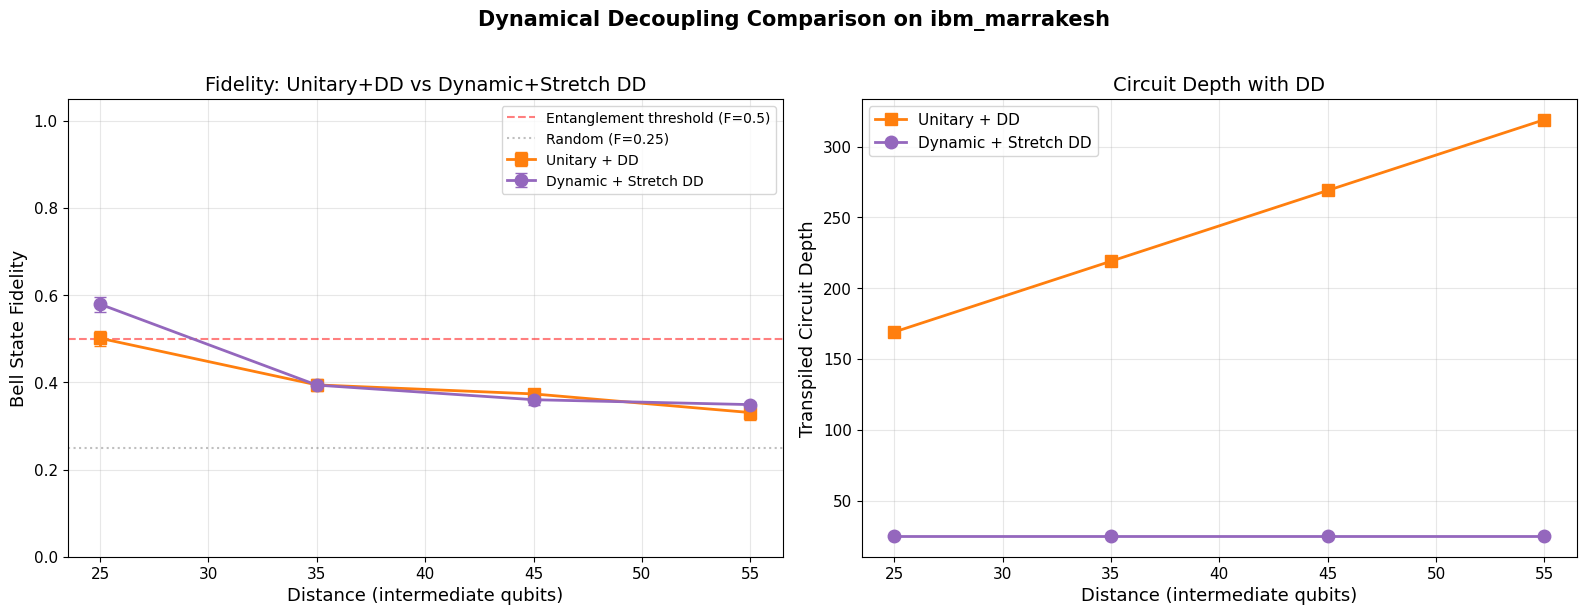

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

dists_dd = DD_DISTANCES

# ---- Left panel: Fidelity comparison ----
u_means = [np.mean(dd_fidelities["uni_dd"][d]) for d in dists_dd]
u_stds  = [np.std(dd_fidelities["uni_dd"][d])  for d in dists_dd]
d_means = [np.mean(dd_fidelities["dyn_stretch"][d]) for d in dists_dd]
d_stds  = [np.std(dd_fidelities["dyn_stretch"][d])  for d in dists_dd]

ax1.errorbar(dists_dd, u_means, yerr=u_stds, fmt='s-', color='#ff7f0e',
             linewidth=2, markersize=9, capsize=4, label='Unitary + DD')
ax1.errorbar(dists_dd, d_means, yerr=d_stds, fmt='o-', color='#9467bd',
             linewidth=2, markersize=9, capsize=4, label='Dynamic + Stretch DD')

ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5,
            label='Entanglement threshold (F=0.5)')
ax1.axhline(y=0.25, color='gray', linestyle=':', alpha=0.5,
            label='Random (F=0.25)')

ax1.set_xlabel('Distance (intermediate qubits)', fontsize=13)
ax1.set_ylabel('Bell State Fidelity', fontsize=13)
ax1.set_title('Fidelity: Unitary+DD vs Dynamic+Stretch DD', fontsize=14)
ax1.legend(fontsize=10, loc='upper right')
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)

# ---- Right panel: Depth comparison ----
u_d = [dd_depth["uni_dd"][d] for d in dists_dd]
d_d = [dd_depth["dyn_stretch"][d] for d in dists_dd]

ax2.plot(dists_dd, u_d, 's-', color='#ff7f0e', linewidth=2,
         markersize=9, label='Unitary + DD')
ax2.plot(dists_dd, d_d, 'o-', color='#9467bd', linewidth=2,
         markersize=9, label='Dynamic + Stretch DD')

ax2.set_xlabel('Distance (intermediate qubits)', fontsize=13)
ax2.set_ylabel('Transpiled Circuit Depth', fontsize=13)
ax2.set_title('Circuit Depth with DD', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle('Dynamical Decoupling Comparison on ' + backend.name,
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 12. Conclusions

### Key Takeaways

1. **Constant vs. Linear Depth**: Dynamic circuits achieve long-range entanglement in **constant depth** (depth ≈ 20 regardless of distance) while the unitary approach scales **linearly** (depth 123 → 223 across d=20–40). This fundamental scaling advantage is clearly confirmed by the transpilation data.

2. **The Crossover — With a Caveat**: A crossover point exists around **d ≈ 35–40** where dynamic circuits begin to outperform unitary ones. However, at this distance **both approaches fall below the entanglement threshold** (F < 0.5), meaning neither produces certifiable entanglement. The crossover is a "least-bad" result on current hardware, not yet a clean victory for dynamic circuits.

3. **Mid-Circuit Measurement Overhead Is Real**: At shorter distances (d=20–30), unitary circuits consistently outperform dynamic ones by ~0.05–0.06 in fidelity. This gap reflects the **measurement latency and readout error penalty** of mid-circuit measurements on Heron r2 processors. As measurement fidelity improves in future hardware generations, this gap will shrink and the crossover will shift to shorter distances.

4. **Stabilizer Fidelity for Entangled States**: This notebook uses stabilizer-based Bell fidelity (F = ¼(1 + ⟨XX⟩ − ⟨YY⟩ + ⟨ZZ⟩)) rather than histogram-based metrics like Hellinger fidelity. Hellinger compares probability distributions and can look good even when entanglement is lost — a classical mixture of |00⟩ and |11⟩ produces the same ZZ histogram as a Bell state. Stabilizer fidelity checks eigenstate membership under all stabilizer generators (XX, ZZ), detecting loss of phase coherence and distinguishing genuine entanglement from classical correlation.

### How This Connects to Broader Quantum Computing

- **Quantum Error Correction**: Syndrome extraction in QEC codes requires long-range entanglement operations. Dynamic circuits enable constant-depth syndrome extraction, which is critical for scaling up fault-tolerant quantum computers.
- **Quantum Algorithms**: Many algorithms (like QAOA, VQE) require entangling operations between distant qubits. Dynamic circuits can reduce the circuit depth of these algorithms on real hardware.

### References
- [IBM Quantum Tutorial: Long-Range Entanglement](https://quantum.cloud.ibm.com/docs/en/tutorials/long-range-entanglement)
- [IBM Blog: Dynamic Circuits for Long-Range Entanglement](https://www.ibm.com/quantum/blog/long-range-entanglement)
- [Efficient Long-Range Entanglement using Dynamic Circuits](https://arxiv.org/abs/2308.13065)
- [IBM Quantum — Stretch Guide](https://quantum.cloud.ibm.com/docs/en/guides/stretch)
- [Qiskit Seminar: Qiskit advocate seminar on dynamic circuits and Samplomatic](https://www.crowdcast.io/c/jan-2026-dynamic-circuits)

In [23]:
# Print environment info for reproducibility
import qiskit
import qiskit_ibm_runtime

print("Environment:")
print(f"  Qiskit SDK:     {qiskit.__version__}")
print(f"  Qiskit Runtime: {qiskit_ibm_runtime.__version__}")
print(f"  NumPy:          {np.__version__}")

Environment:
  Qiskit SDK:     2.3.0
  Qiskit Runtime: 0.41.1
  NumPy:          2.3.3
